In [227]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pylab import rcParams


In [228]:
sql= "select * from acc_ord_card_disp_client_dist aocdcd join loan_trans lt on lt.account_id= aocdcd.account_id" 

In [229]:
import mysql.connector as connection
try:
    mydb = connection.connect(host="localhost", database = 'capstone_prj', user="root", passwd="Rohan@777",use_pure=True)
    df = pd.read_sql(sql,mydb)
    mydb.close() #close the connection
except Exception as e:
    mydb.close()
    print(str(e))

C:\Users\ROHAN\AppData\Local\Temp\ipykernel_4100\2325888468.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql,mydb)


In [230]:
df

,card_id,disp_id,type,issued,account_id,disposition_client_id,disposition_type,client_id,birth_number,district_id,...,balance,k_symbol,bank,account,loan_id,loan_date,loan_amount,duration,payments,status
0,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19916.6,UROK,,,5325,930803,105804,36,2939.0,A
1,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,26099.1,,,,5325,930803,105804,36,2939.0,A
2,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19799.1,,,,5325,930803,105804,36,2939.0,A
3,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,24499.1,SIPO,QR,62958741,5325,930803,105804,36,2939.0,A
4,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,31493.1,UVER,QR,70984434,5325,930803,105804,36,2939.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1036,9735,classic,970117 00:00:00,8129,10043,OWNER,10043,651029,45,...,700.0,,,,6668,940730,74736,36,2076.0,A
864,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,54840.0,,GH,84269058,6678,940520,80340,12,6695.0,A
865,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,14000.0,,,,6678,940520,80340,12,6695.0,A
866,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,1100.0,,,,6678,940520,80340,12,6695.0,A


In [231]:
df.shape

(868, 50)

In [232]:
df.columns

Index(['card_id', 'disp_id', 'type', 'issued', 'account_id',
       'disposition_client_id', 'disposition_type', 'client_id',
       'birth_number', 'district_id', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7',
       'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'order_id',
       'bank_to', 'account_to', 'amount', 'k_symbol', 'account_date',
       'account_district_id', 'frequency', 'trans_id', 'account_id', 'date',
       'type', 'operation', 'amount', 'balance', 'k_symbol', 'bank', 'account',
       'loan_id', 'loan_date', 'loan_amount', 'duration', 'payments',
       'status'],
      dtype='object')

In [233]:
df.isnull().sum()

card_id                  0
disp_id                  0
type                     0
issued                   0
account_id               0
disposition_client_id    0
disposition_type         0
client_id                0
birth_number             0
district_id              0
A1                       0
A2                       0
A3                       0
A4                       0
A5                       0
A6                       0
A7                       0
A8                       0
A9                       0
A10                      0
A11                      0
A12                      0
A13                      0
A14                      0
A15                      0
A16                      0
order_id                 0
bank_to                  0
account_to               0
amount                   0
k_symbol                 0
account_date             0
account_district_id      0
frequency                0
trans_id                 0
account_id               0
date                     0
t

In [234]:
df.duration.unique()

array([36, 12, 48, 24, 60])

In [235]:
df.status.value_counts()

status
A    648
B    168
C     51
D      1
Name: count, dtype: int64

In [236]:
df.balance.value_counts()

balance
200.0      14
900.0       9
300.0       8
700.0       6
15736.4     5
           ..
41130.1     1
45024.1     1
54840.0     1
14000.0     1
400.0       1
Name: count, Length: 372, dtype: int64

In [237]:
df.status=pd.DataFrame(df.status.map({'A':0,'B':1,'C':2,'D':3}),
columns=['status'])
display (df.status)


0      0
1      0
2      0
3      0
4      0
      ..
863    0
864    0
865    0
866    0
867    0
Name: status, Length: 868, dtype: int64

In [238]:
df.status.value_counts()

status
0    648
1    168
2     51
3      1
Name: count, dtype: int64

In [239]:
x=df[['loan_amount', 'duration', 'payments']].values
x

array([[1.05804e+05, 3.60000e+01, 2.93900e+03],
       [1.05804e+05, 3.60000e+01, 2.93900e+03],
       [1.05804e+05, 3.60000e+01, 2.93900e+03],
       ...,
       [8.03400e+04, 1.20000e+01, 6.69500e+03],
       [8.03400e+04, 1.20000e+01, 6.69500e+03],
       [2.82480e+04, 2.40000e+01, 1.17700e+03]])

In [240]:
y=df['status'].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [241]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
x=mms.fit_transform(x)
x

array([[0.28768316, 0.5       , 0.28866317],
       [0.28768316, 0.5       , 0.28866317],
       [0.28768316, 0.5       , 0.28866317],
       ...,
       [0.20733785, 0.        , 0.90399738],
       [0.20733785, 0.        , 0.90399738],
       [0.04297452, 0.25      , 0.        ]])

In [242]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.3, random_state=7)
print(x.shape)
print(y.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(868, 3)
(868,)
(607, 3)
(261, 3)
(607,)
(261,)


In [243]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
accuracy=[]
confusion_matrix=[]
classification_report=[]
for i in range(1,15):
    knc=KNeighborsClassifier(n_neighbors=i)
    knc.fit(x_train, y_train)
    y_pred=knc.predict(x_test)
    acc=r2_score(y_test, y_pred)
    accuracy.append(acc)


In [244]:
accuracy

[0.9413658828815337,
 0.9413658828815337,
 0.9413658828815337,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227,
 0.9022764714692227]

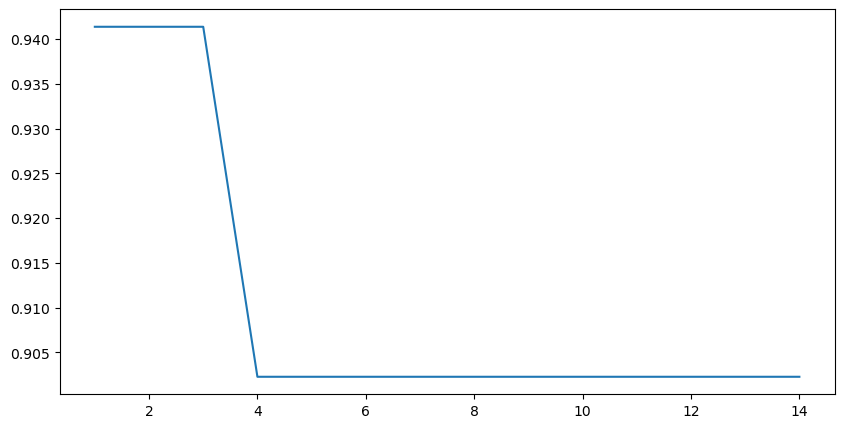

In [245]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=10,5
plt.plot(range(1,15), accuracy)
plt.show()

In [246]:
from sklearn.neighbors import KNeighborsClassifier
knc=KNeighborsClassifier(n_neighbors=3)
knc.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [247]:
knc_y_pred=knc.predict(x_test)
knc_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0])

In [248]:
knc_diff=y_test-knc_y_pred
knc_diff

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [249]:
knc_report=pd.concat([pd.DataFrame(y_test, columns=['Actual Value']), 
                      pd.DataFrame(knc_y_pred, columns=['Predicted Value']),
                      pd.DataFrame(knc_diff, columns=['Difference'])], axis=1)
knc_report

,Actual Value,Predicted Value,Difference
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
256,2,2,0
257,0,0,0
258,0,0,0
259,0,0,0


In [250]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test, knc_y_pred)
acc

0.9885057471264368

In [251]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, knc_y_pred)
cm

array([[192,   2,   0,   0],
       [  0,  47,   0,   0],
       [  0,   0,  19,   0],
       [  0,   1,   0,   0]])

In [252]:
from sklearn.metrics import classification_report
cr=classification_report(y_test, knc_y_pred, zero_division=0)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       194
           1       0.94      1.00      0.97        47
           2       1.00      1.00      1.00        19
           3       0.00      0.00      0.00         1

    accuracy                           0.99       261
   macro avg       0.73      0.75      0.74       261
weighted avg       0.99      0.99      0.99       261



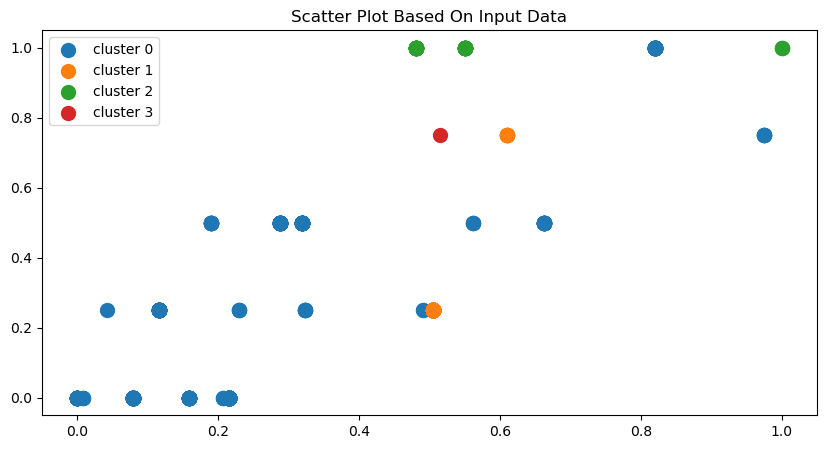

In [253]:
plt.scatter(x[y==0,0], x[y==0,1], s=100, label='cluster 0')
plt.scatter(x[y==1,0], x[y==1,1], s=100, label='cluster 1')
plt.scatter(x[y==2,0], x[y==2,1], s=100, label='cluster 2')
plt.scatter(x[y==3,0], x[y==3,1], s=100, label='cluster 3')
plt.title('Scatter Plot Based On Input Data')
plt.legend()
plt.show()

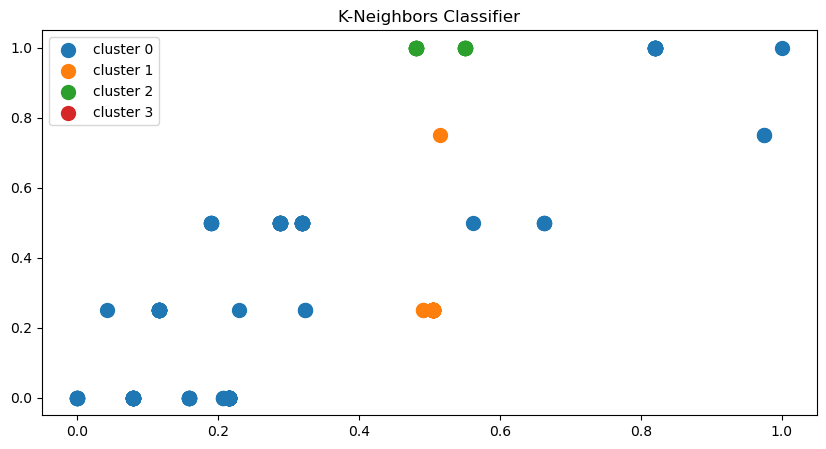

In [254]:

plt.scatter(x_test[y_pred==0,0], x_test[y_pred==0,1], s=100, label='cluster 0')
plt.scatter(x_test[y_pred==1,0], x_test[y_pred==1,1], s=100, label='cluster 1')
plt.scatter(x_test[y_pred==2,0], x_test[y_pred==2,1], s=100, label='cluster 2')
plt.scatter(x_test[y_pred==3,0], x_test[y_pred==3,1], s=100, label='cluster 3')
plt.title('K-Neighbors Classifier')
plt.legend()
plt.show()

In [255]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train, y_train)


LogisticRegression()

In [256]:
lr_y_pred=lr.predict(x_test)
lr_y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [257]:
lr_diff=y_test-lr_y_pred

In [258]:
lr_report=pd.concat([pd.DataFrame(y_test, columns=['Actual Value']), 
                     pd.DataFrame(lr_y_pred, columns=['Predicted Value']),
                     pd.DataFrame(lr_diff, columns=['Difference'])], axis=1)
lr_report


,Actual Value,Predicted Value,Difference
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
256,2,0,2
257,0,0,0
258,0,0,0
259,0,0,0


In [259]:
from sklearn.metrics import accuracy_score
lr_acc=accuracy_score(y_test, lr_y_pred)
lr_acc

0.9080459770114943

In [260]:
from sklearn.metrics import confusion_matrix
lr_cm=confusion_matrix(y_test, lr_y_pred)
lr_cm

array([[190,   4,   0,   0],
       [  0,  47,   0,   0],
       [ 18,   1,   0,   0],
       [  1,   0,   0,   0]])

In [261]:
from sklearn.metrics import classification_report
lr_cr=classification_report(y_test, lr_y_pred, zero_division=0)
print(lr_cr)

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       194
           1       0.90      1.00      0.95        47
           2       0.00      0.00      0.00        19
           3       0.00      0.00      0.00         1

    accuracy                           0.91       261
   macro avg       0.45      0.49      0.47       261
weighted avg       0.84      0.91      0.87       261



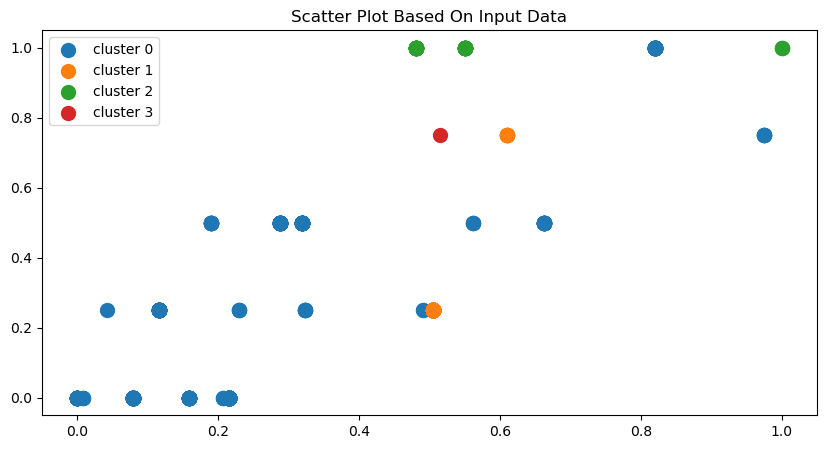

In [262]:

plt.scatter(x[y==0,0], x[y==0,1], s=100, label='cluster 0')
plt.scatter(x[y==1,0], x[y==1,1], s=100, label='cluster 1')
plt.scatter(x[y==2,0], x[y==2,1], s=100, label='cluster 2')
plt.scatter(x[y==3,0], x[y==3,1], s=100, label='cluster 3')
plt.title('Scatter Plot Based On Input Data')
plt.legend()
plt.show()

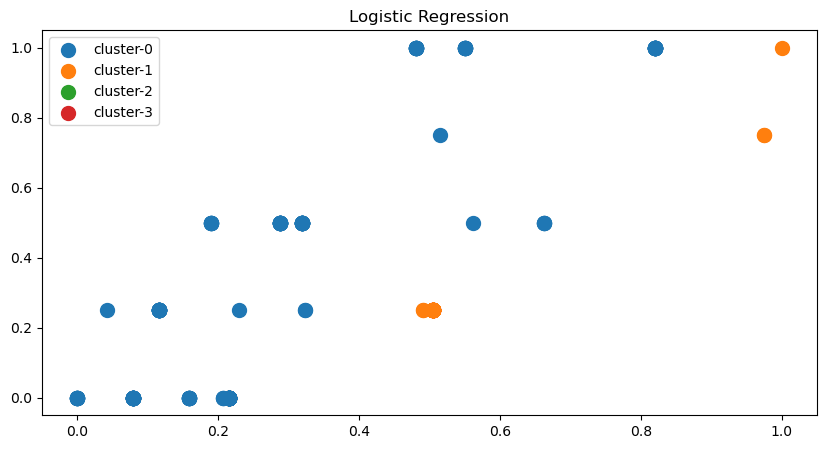

In [263]:

plt.scatter(x_test[lr_y_pred==0,0], x_test[lr_y_pred==0,1], s=100, label='cluster-0')
plt.scatter(x_test[lr_y_pred==1,0], x_test[lr_y_pred==1,1], s=100, label='cluster-1')
plt.scatter(x_test[lr_y_pred==2,0], x_test[lr_y_pred==2,1], s=100, label='cluster-2')
plt.scatter(x_test[lr_y_pred==3,0], x_test[lr_y_pred==3,1], s=100, label='cluster-3')
plt.title('Logistic Regression')
plt.legend()
plt.show()

In [264]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(criterion='entropy')
dtc.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [265]:
dtc_y_pred=dtc.predict(x_test)
dtc_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0])

In [266]:
dtc_diff=y_test-dtc_y_pred
dtc_diff

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [267]:
dtc_report=pd.concat([pd.DataFrame(y_test, columns=['Actual Value']), 
                      pd.DataFrame(dtc_y_pred, columns=['Predicted Value']),
                      pd.DataFrame(dtc_diff, columns=['Difference'])], axis=1)
dtc_report


,Actual Value,Predicted Value,Difference
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
256,2,2,0
257,0,0,0
258,0,0,0
259,0,0,0


In [268]:
from sklearn.metrics import accuracy_score
dtc_acc=accuracy_score(y_test, dtc_y_pred)
dtc_acc

0.9961685823754789

In [269]:
from sklearn.metrics import confusion_matrix
dtc_cm=confusion_matrix(y_test, dtc_y_pred)
dtc_cm

array([[194,   0,   0,   0],
       [  0,  47,   0,   0],
       [  0,   0,  19,   0],
       [  0,   0,   1,   0]])

In [270]:
from sklearn.metrics import classification_report
dtc_cr=classification_report(y_test, dtc_y_pred, zero_division=0)
print(dtc_cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       194
           1       1.00      1.00      1.00        47
           2       0.95      1.00      0.97        19
           3       0.00      0.00      0.00         1

    accuracy                           1.00       261
   macro avg       0.74      0.75      0.74       261
weighted avg       0.99      1.00      0.99       261



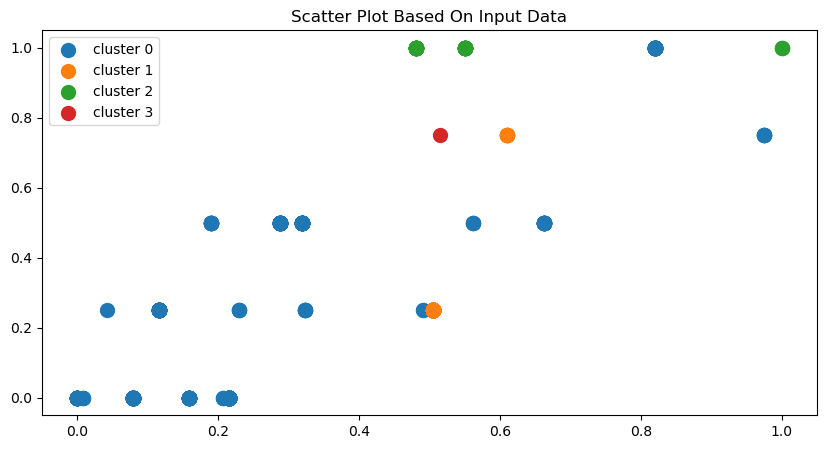

In [271]:
plt.scatter(x[y==0,0], x[y==0,1], s=100, label='cluster 0')
plt.scatter(x[y==1,0], x[y==1,1], s=100, label='cluster 1')
plt.scatter(x[y==2,0], x[y==2,1], s=100, label='cluster 2')
plt.scatter(x[y==3,0], x[y==3,1], s=100, label='cluster 3')
plt.title('Scatter Plot Based On Input Data')
plt.legend()
plt.show()

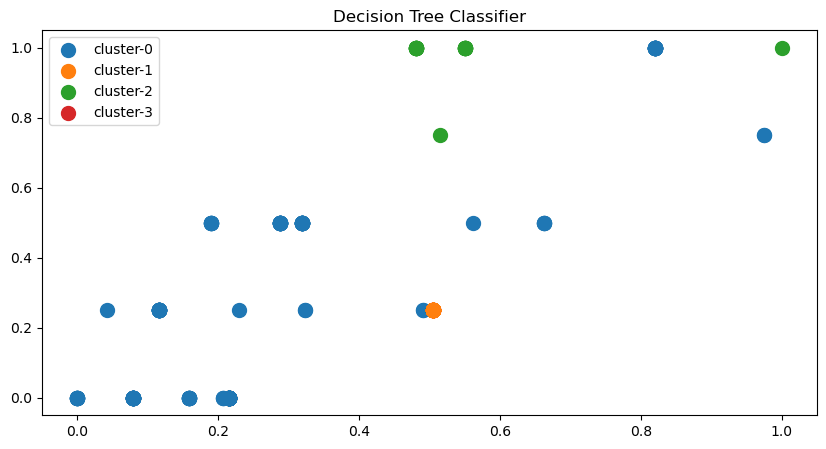

In [272]:

plt.scatter(x_test[dtc_y_pred==0,0], x_test[dtc_y_pred==0,1], s=100, label='cluster-0')
plt.scatter(x_test[dtc_y_pred==1,0], x_test[dtc_y_pred==1,1], s=100, label='cluster-1')
plt.scatter(x_test[dtc_y_pred==2,0], x_test[dtc_y_pred==2,1], s=100, label='cluster-2')
plt.scatter(x_test[dtc_y_pred==3,0], x_test[dtc_y_pred==3,1], s=100, label='cluster-3')
plt.title('Decision Tree Classifier')
plt.legend()
plt.show()

In [273]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=50, criterion='entropy')
rfc.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=50)

In [274]:
rfc_y_pred=rfc.predict(x_test)
rfc_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0])

In [275]:
rfc_diff=y_test-rfc_y_pred
rfc_diff

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [276]:
rfc_report=pd.concat([pd.DataFrame(y_test, columns=['Actual Value']),
                      pd.DataFrame(rfc_y_pred, columns=['Predicted Value']),
                      pd.DataFrame(rfc_diff, columns=['Difference'])], axis=1)
rfc_report

,Actual Value,Predicted Value,Difference
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
256,2,2,0
257,0,0,0
258,0,0,0
259,0,0,0


In [277]:
from sklearn.metrics import accuracy_score
rfc_acc=accuracy_score(y_test, rfc_y_pred)
rfc_acc

0.9885057471264368

In [278]:
from sklearn.metrics import confusion_matrix
rfc_cm=confusion_matrix(y_test, rfc_y_pred)
rfc_cm

array([[192,   2,   0,   0],
       [  0,  47,   0,   0],
       [  0,   0,  19,   0],
       [  0,   1,   0,   0]])

In [279]:
from sklearn.metrics import classification_report
rfc_cr=classification_report(y_test, rfc_y_pred, zero_division=1)
print(rfc_cr)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       194
           1       0.94      1.00      0.97        47
           2       1.00      1.00      1.00        19
           3       1.00      0.00      0.00         1

    accuracy                           0.99       261
   macro avg       0.98      0.75      0.74       261
weighted avg       0.99      0.99      0.99       261



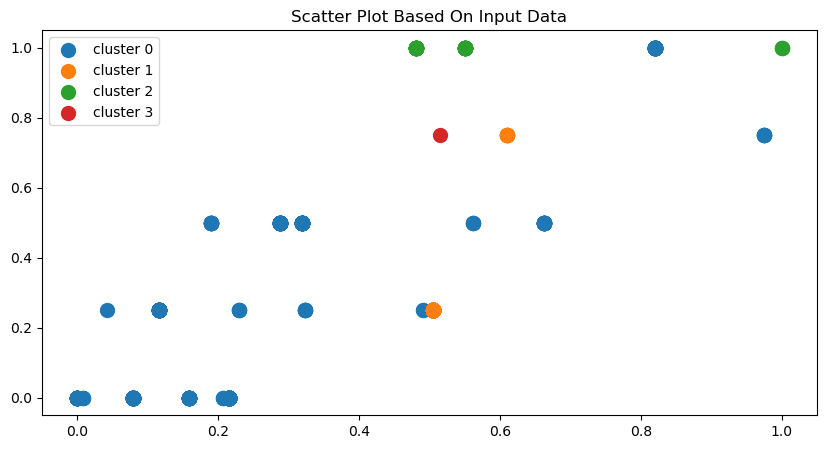

In [280]:
plt.scatter(x[y==0,0], x[y==0,1], s=100, label='cluster 0')
plt.scatter(x[y==1,0], x[y==1,1], s=100, label='cluster 1')
plt.scatter(x[y==2,0], x[y==2,1], s=100, label='cluster 2')
plt.scatter(x[y==3,0], x[y==3,1], s=100, label='cluster 3')
plt.title('Scatter Plot Based On Input Data')
plt.legend()
plt.show()

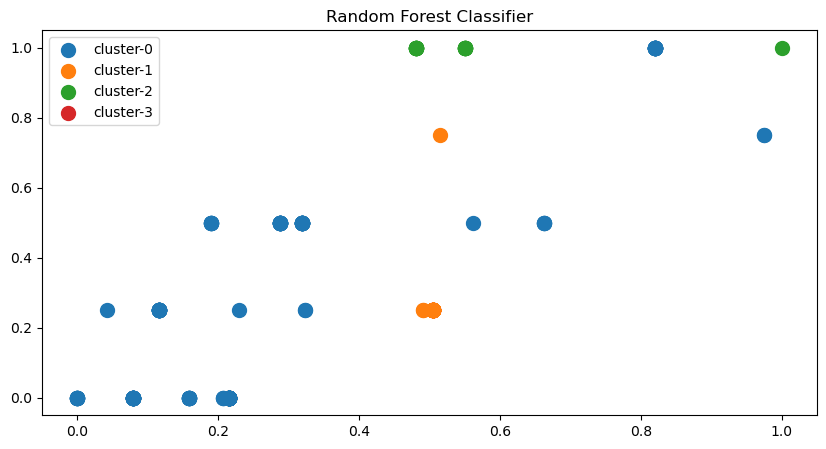

In [281]:
plt.scatter(x_test[rfc_y_pred==0,0], x_test[rfc_y_pred==0,1], s=100, label='cluster-0')
plt.scatter(x_test[rfc_y_pred==1,0], x_test[rfc_y_pred==1,1], s=100, label='cluster-1')
plt.scatter(x_test[rfc_y_pred==2,0], x_test[rfc_y_pred==2,1], s=100, label='cluster-2')
plt.scatter(x_test[rfc_y_pred==3,0], x_test[rfc_y_pred==3,1], s=100, label='cluster-3')
plt.title('Random Forest Classifier')
plt.legend()
plt.show()